In [1]:
# Librerias 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
import scienceplots

In [2]:
plt.style.use(['science','ieee'])

In [3]:
# carga de datos
df=pd.read_csv('datos.csv')
T_celsius=df['Temperatura_C'].values
T_kelvin=T_celsius+273.15

In [4]:
# Funciones de ajuste
def modelo_lineal(t, m, b):
    return m*t+b
def modelo_ntc(t_k, B, R0_fit): 
    T0=25+273.15
    R_fija=100000
    R_ntc = R0_fit * np.exp(B * (1/t_k - 1/T0))
    return 5*(R_ntc/(R_ntc+R_fija))

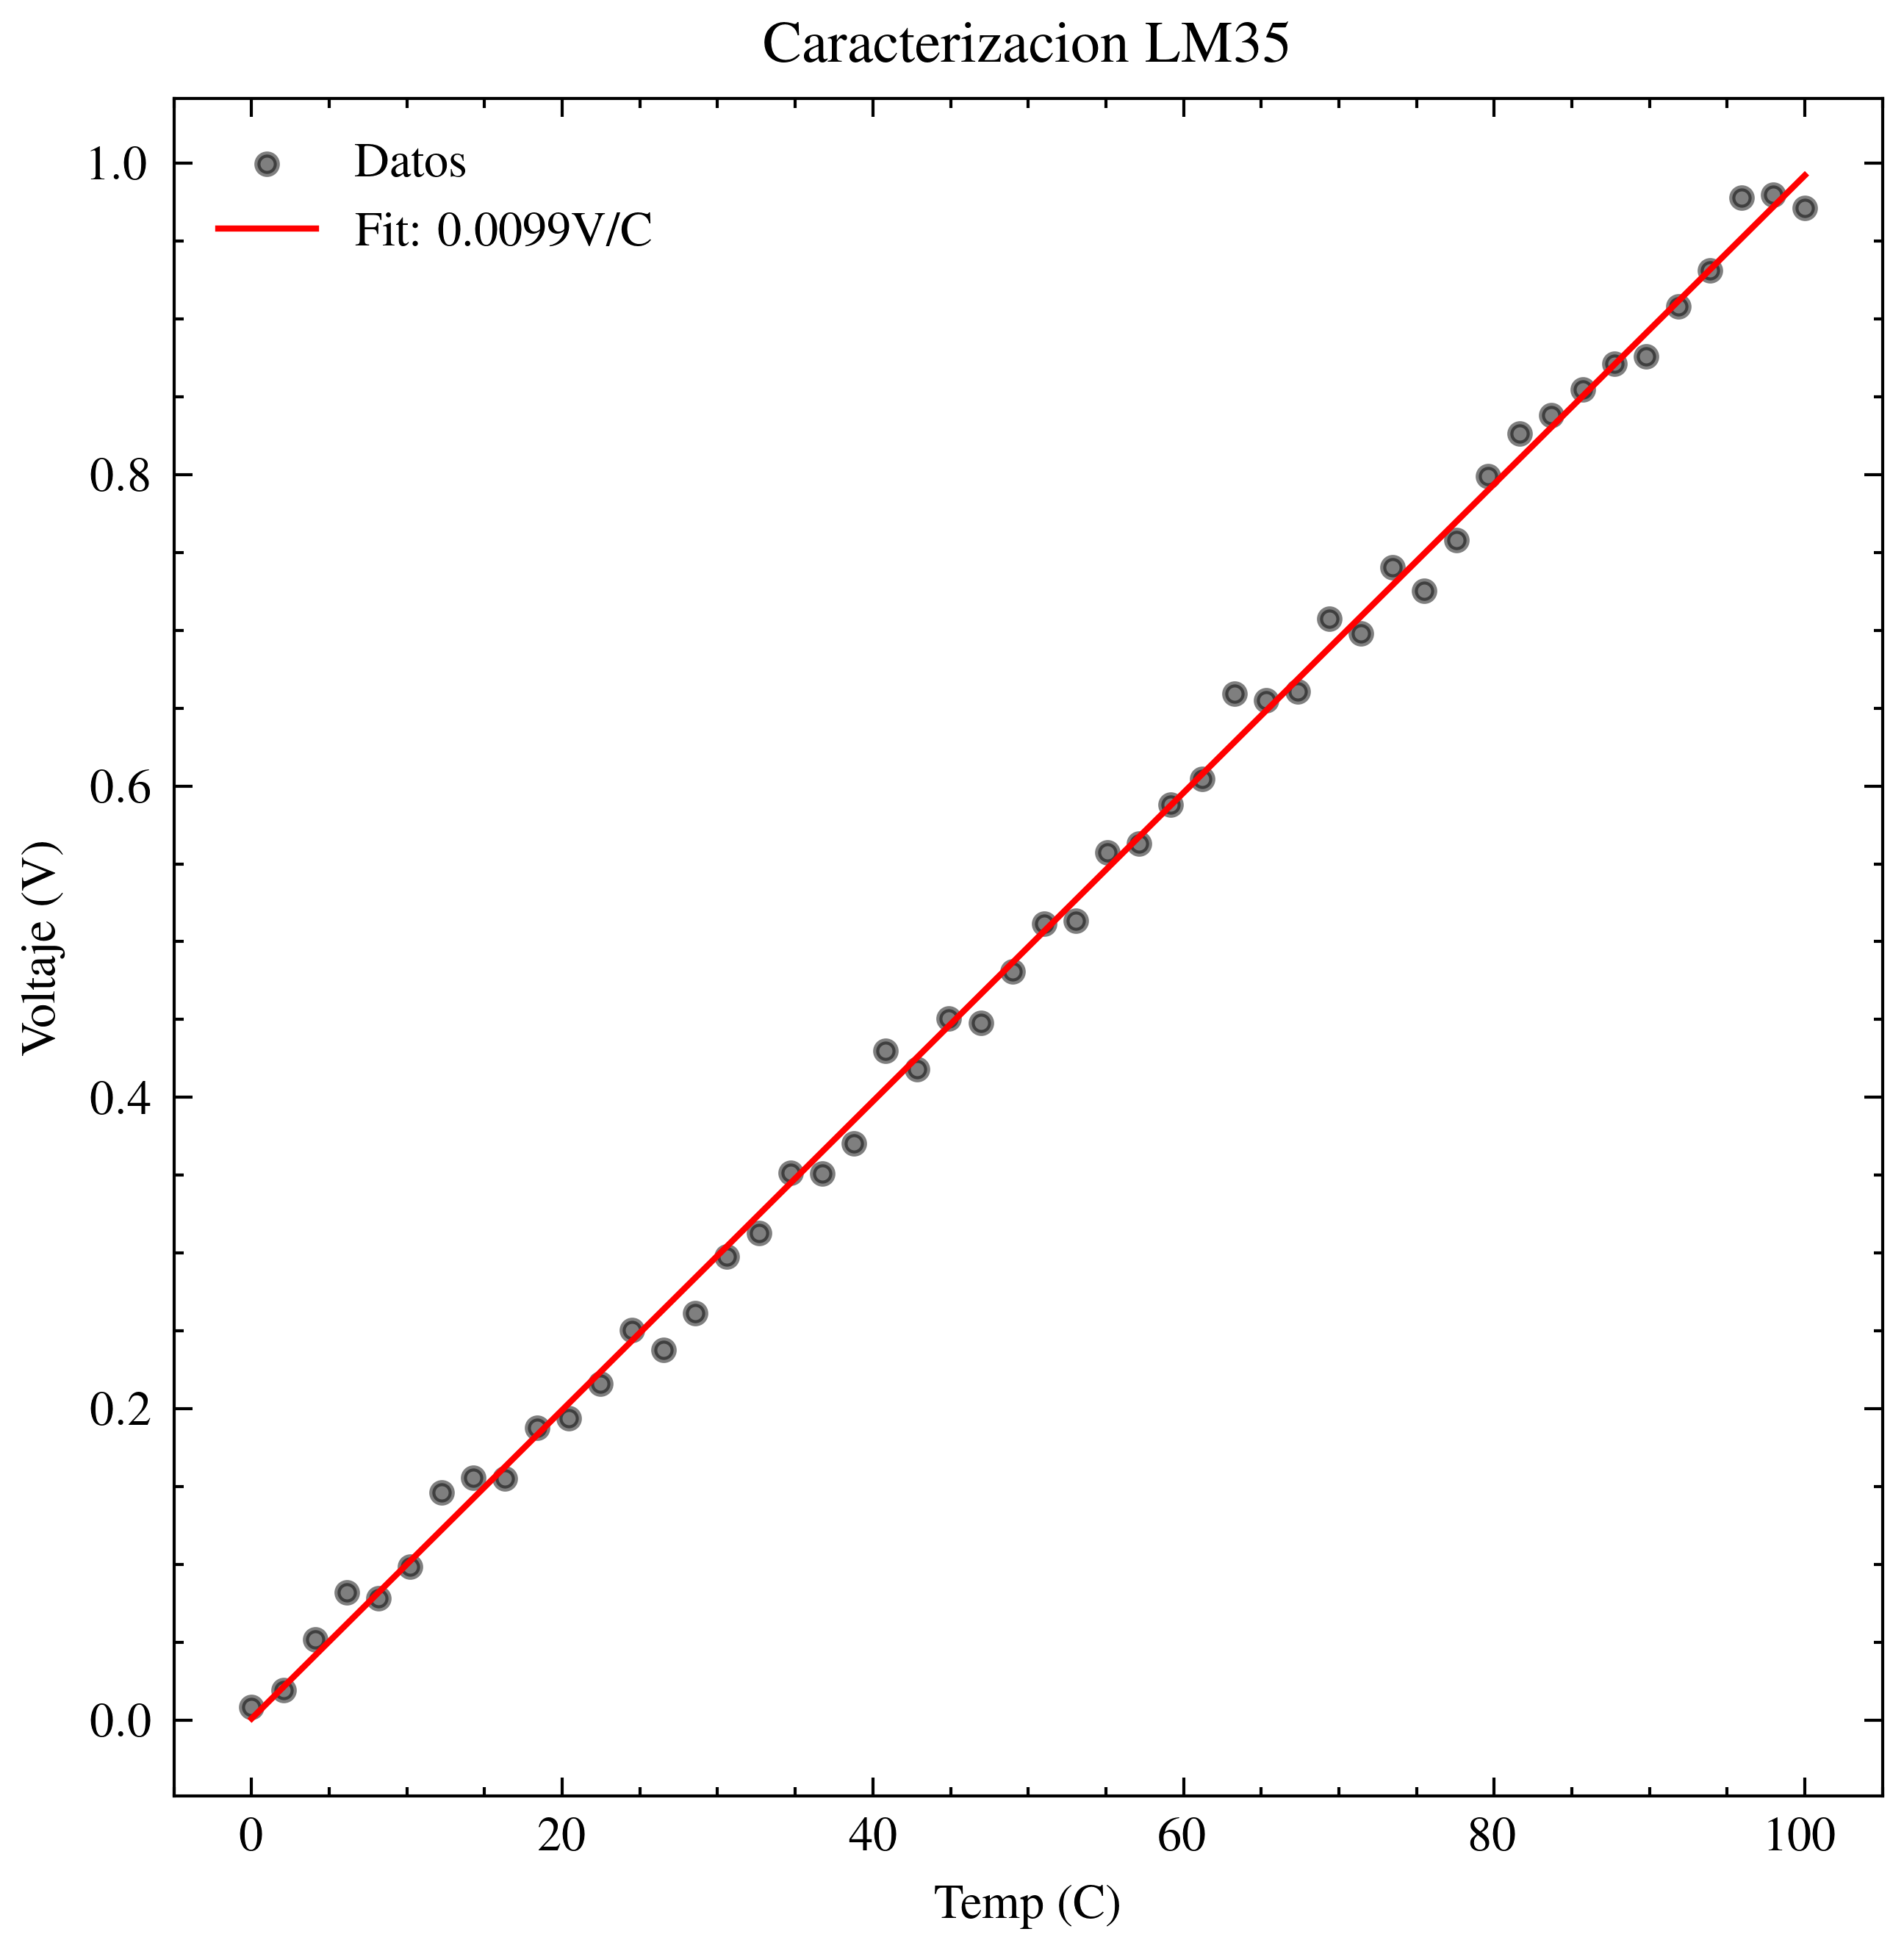

In [5]:
#Analisis LM35
popt_lm, _=curve_fit(modelo_lineal, T_celsius, df['LM35_V'])
m_lm, b_lm=popt_lm
plt.figure(figsize=(5, 5))
plt.scatter(T_celsius, df['LM35_V'], label='Datos', s=10, alpha=0.5)
plt.plot(T_celsius, modelo_lineal(T_celsius, *popt_lm), 'r', label=f'Fit: {m_lm:.4f}V/C')
plt.title('Caracterizacion LM35')
plt.xlabel('Temp (C)'); plt.ylabel('Voltaje (V)'); plt.legend()
plt.savefig('LM35_plot')

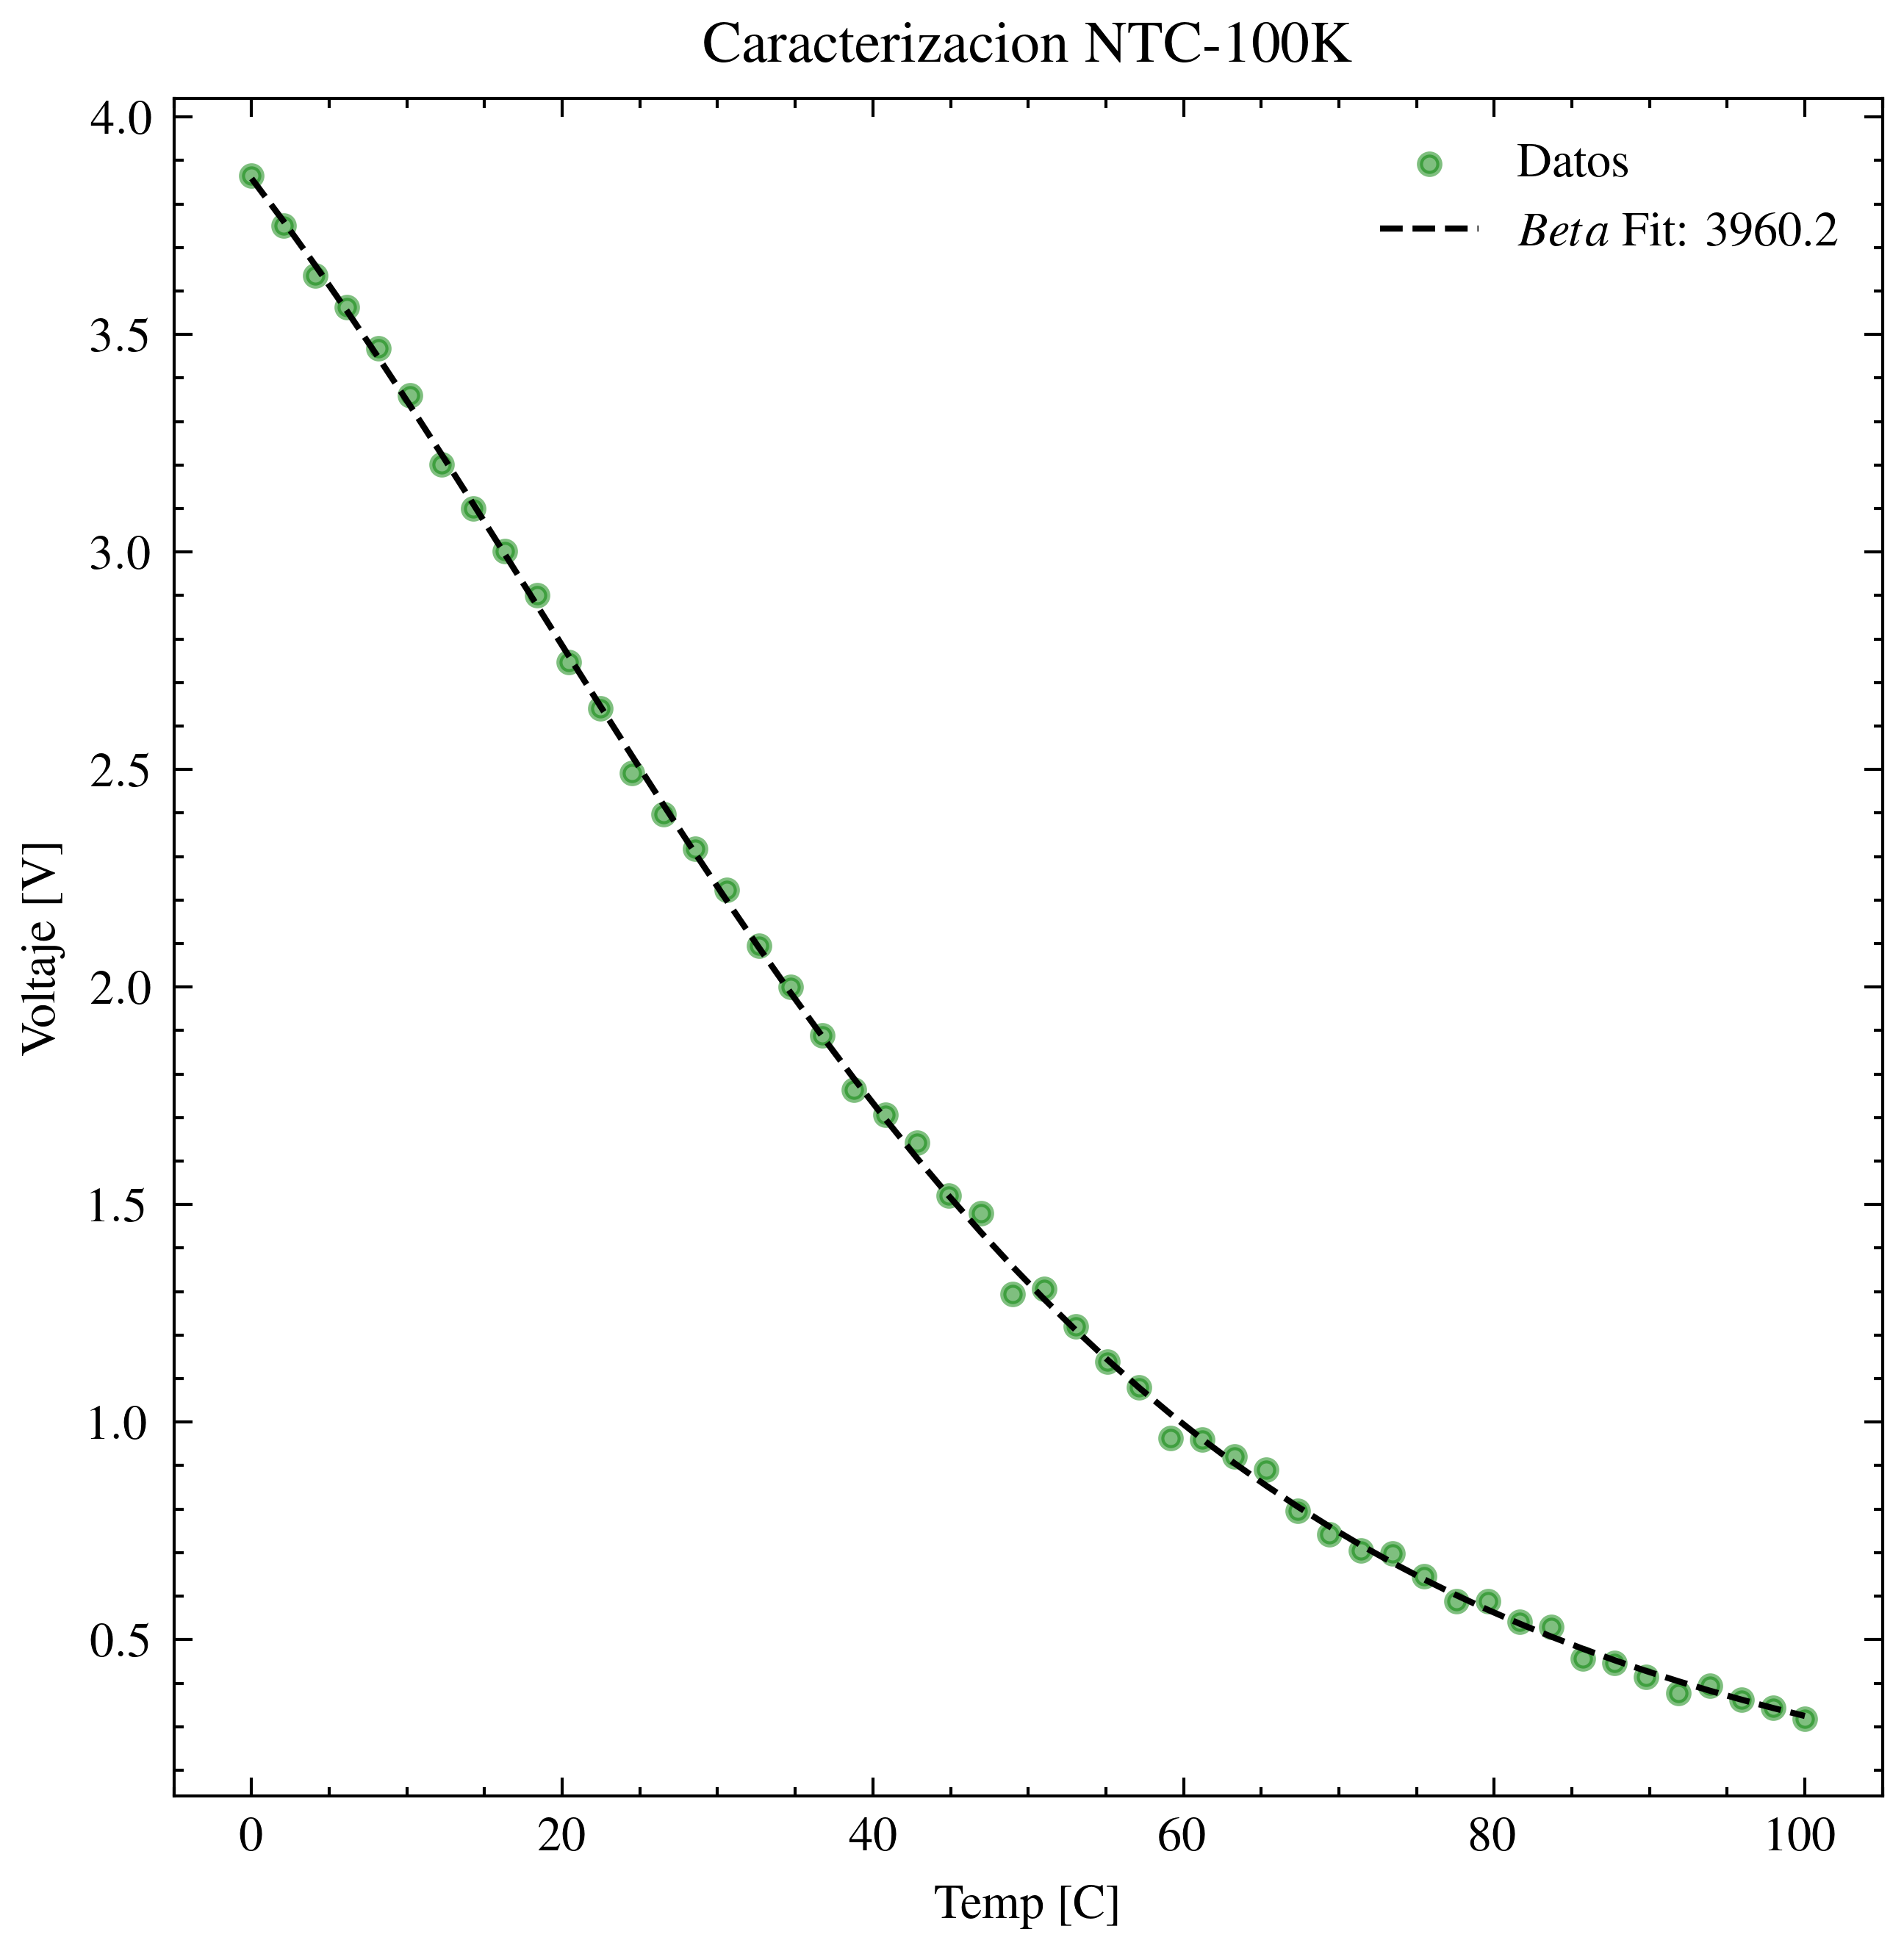

In [6]:
#Analisis NTC-100K
popt_ntc, _=curve_fit(modelo_ntc, T_kelvin, df['NTC100K_V'], p0=[3950, 100000])
B_fit, R0_fit=popt_ntc
plt.figure(figsize=(5,5))
plt.scatter(T_celsius, df['NTC100K_V'], label='Datos', s=10, alpha=0.5, color='green')
plt.plot(T_celsius, modelo_ntc(T_kelvin, *popt_ntc), 'k--', label=f'$ Beta $ Fit: {B_fit:.1f}')
plt.title('Caracterizacion NTC-100K')
plt.xlabel('Temp [C]'); plt.ylabel('Voltaje [V]'); plt.legend()
plt.savefig('NTC_plot')

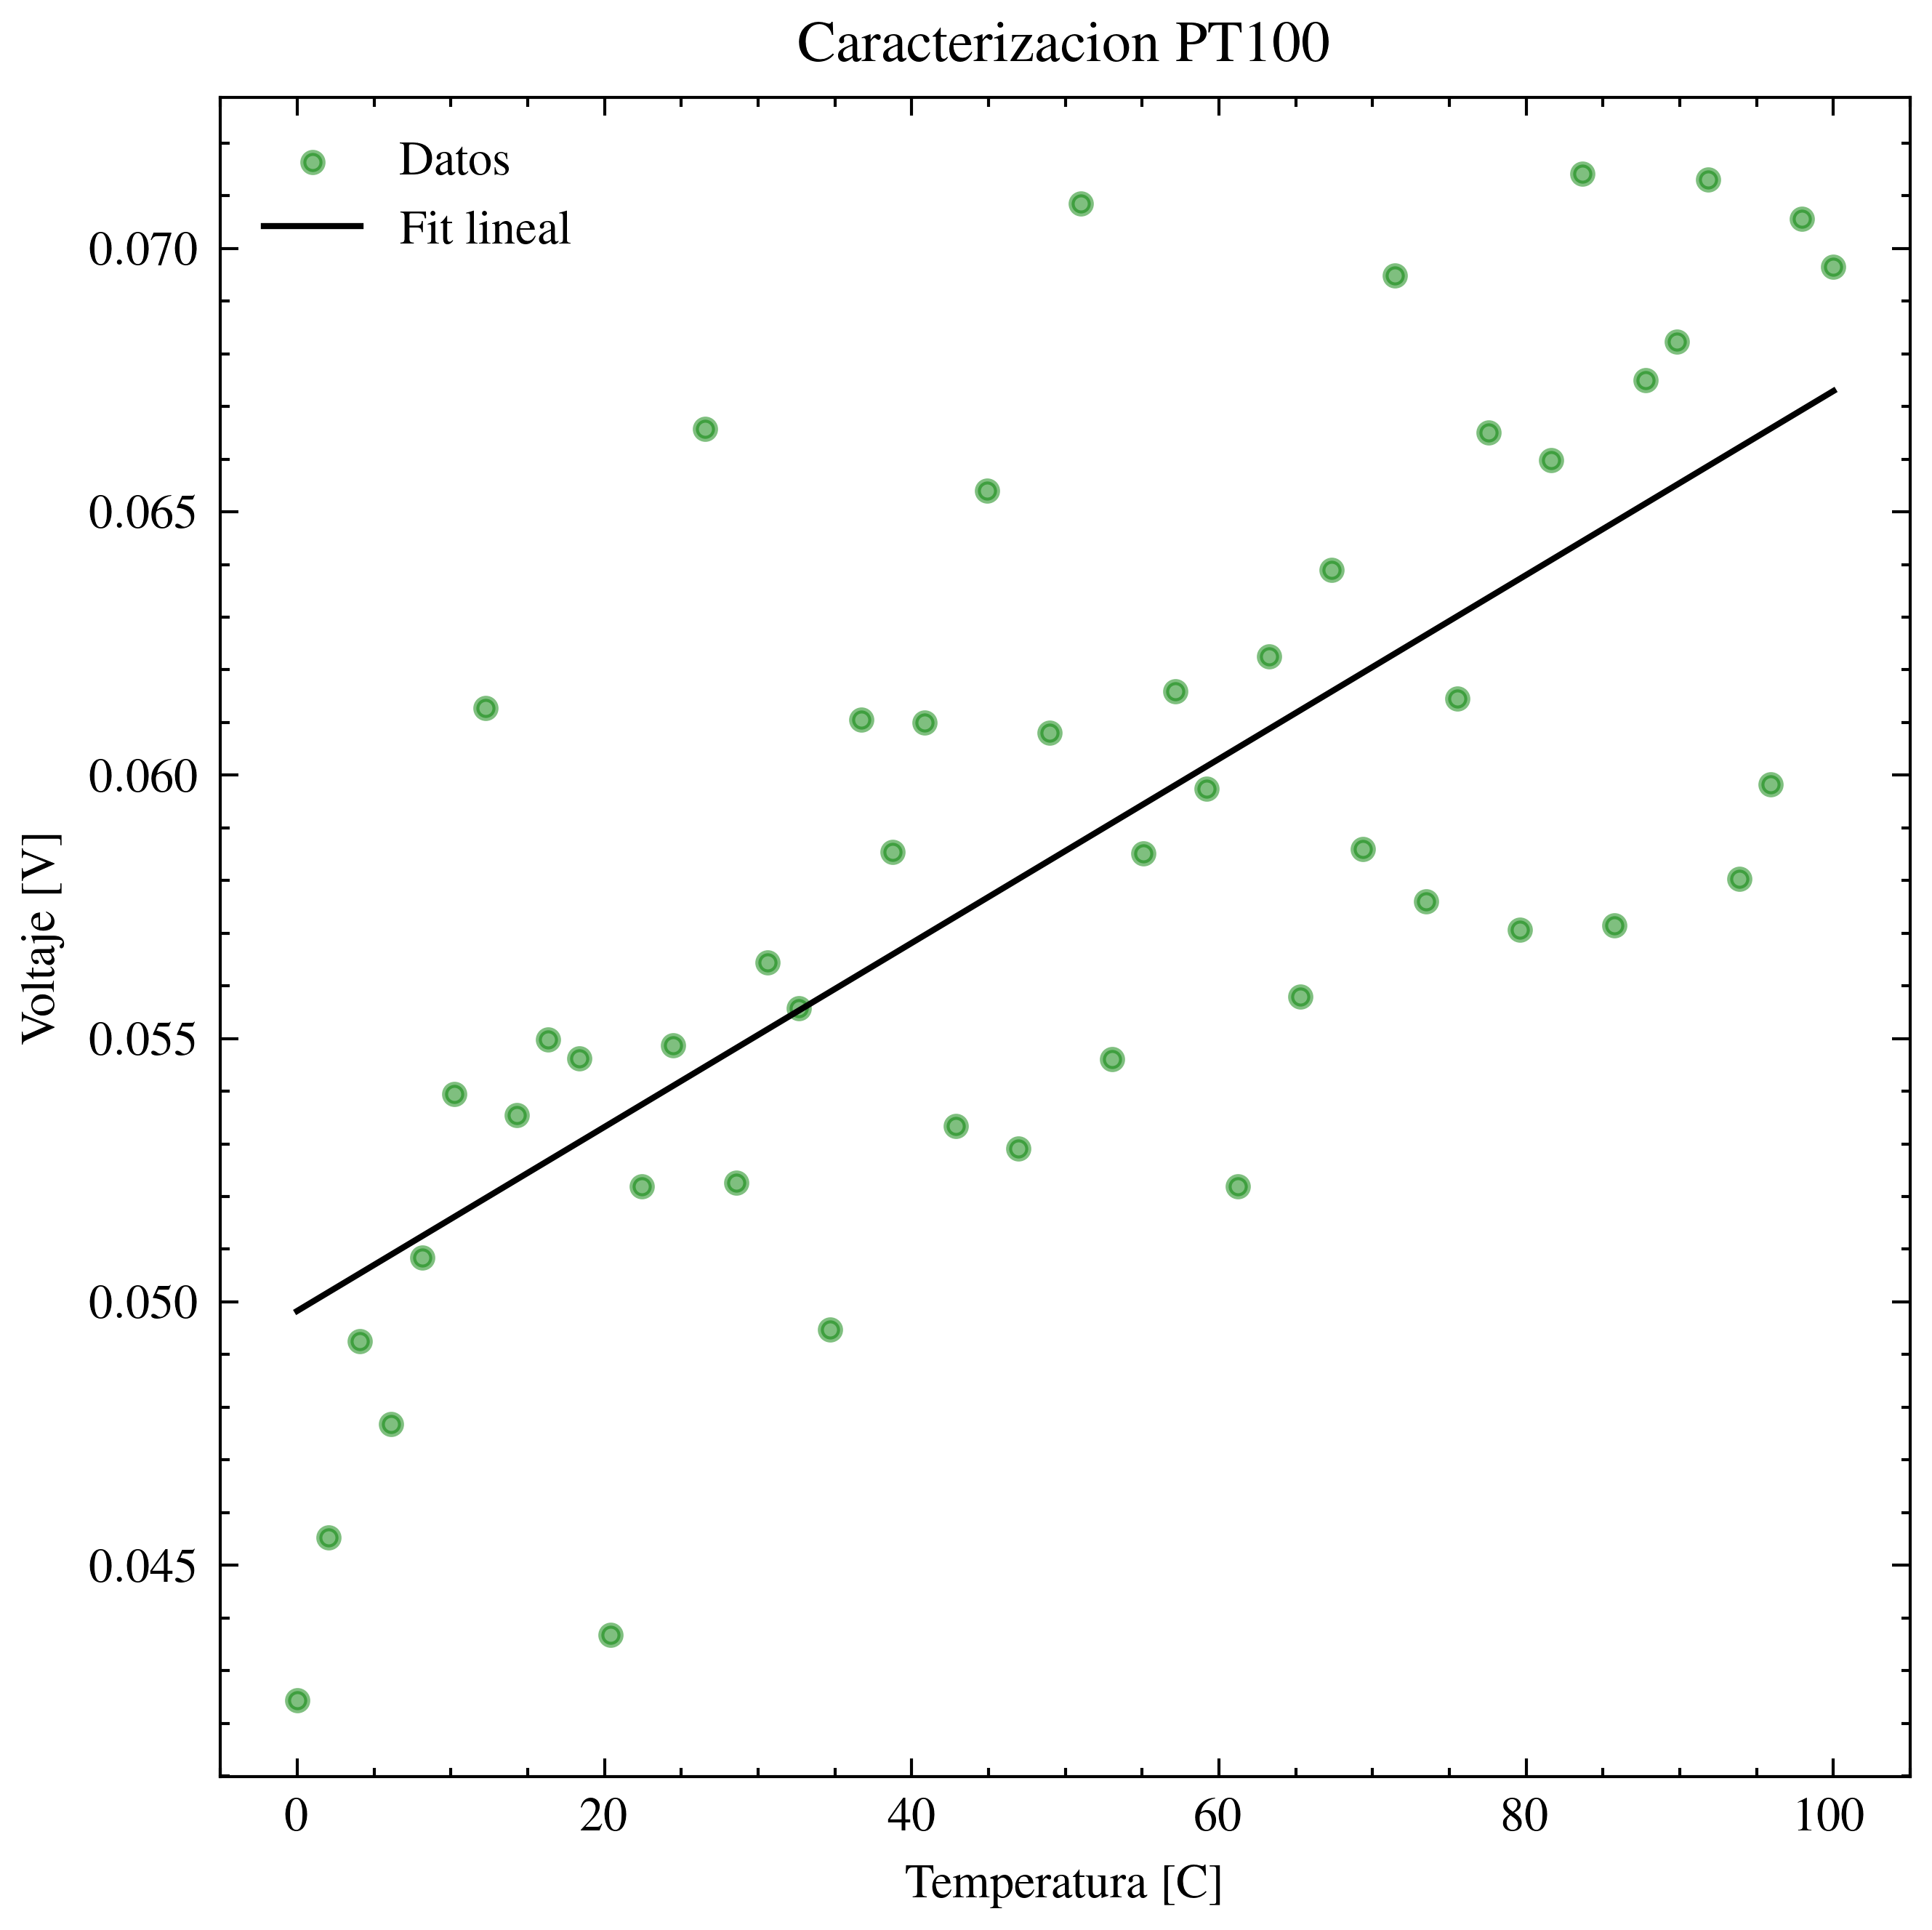

In [7]:
# Analisis PT100 (aproximacion lineal)
popt_pt, _=curve_fit(modelo_lineal, T_celsius, df['PT100_V'])
plt.figure(figsize=(5,5))
plt.scatter(T_celsius, df['PT100_V'], label='Datos', s=10, alpha=0.5, color='green')
plt.plot(T_celsius, modelo_lineal(T_celsius, *popt_pt),'k', label='Fit lineal')
plt.title('Caracterizacion PT100')
plt.xlabel('Temperatura [C]'); plt.ylabel('Voltaje [V]'); plt.legend()
plt.savefig('PT100_plot')

In [8]:
print("-" * 30)
print("VALORES CARACTERÍSTICOS:")
print(f"LM35 - Sensibilidad real: {m_lm*1000:.2f} mV/°C (Teórico: 10.0)")
print(f"NTC  - Constante Beta (β): {B_fit:.2f} K")
print(f"PT100 - Pendiente del divisor: {popt_pt[0]:.6f} V/°C")
print("-" * 30)

------------------------------
VALORES CARACTERÍSTICOS:
LM35 - Sensibilidad real: 9.91 mV/°C (Teórico: 10.0)
NTC  - Constante Beta (β): 3960.15 K
PT100 - Pendiente del divisor: 0.000175 V/°C
------------------------------
